## Objective
Build a Random Forest classification model to predict whether a patient will experience heart failure.

## Dataset
Heart Failure Prediction Dataset (https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)
- Load the dataset using pandas
- Perform basic Exploratory Data Analysis (EDA)
- Data Preprocessing
- Split the dataset into training and testing sets
- Train a Random Forest Classifier using scikit-learn
## Evaluate the model using:
Accuracy
Confusion Matrix
Classification Report
Briefly explain the model results and important features

## download data

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\moust\.cache\kagglehub\datasets\fedesoriano\heart-failure-prediction\versions\1


## import libraries

In [170]:
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [184]:
warnings.filterwarnings('ignore')

## read data

In [7]:
os.listdir(path)

['heart.csv']

In [8]:
data=pd.read_csv(path+'/heart.csv')

In [9]:
data.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [10]:
data.shape

(918, 12)

## data preprocessing

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [13]:
data.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [14]:
for i in data.columns:
    if data[i].dtype==object:
        print(data[i].value_counts())
        print('_________________')

Sex
M    725
F    193
Name: count, dtype: int64
_________________
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
_________________
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
_________________
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
_________________
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64
_________________


In [15]:
le = LabelEncoder()

data['Sex'] = le.fit_transform(data['Sex'])
data['ExerciseAngina'] = le.fit_transform(data['ExerciseAngina'])

In [16]:
data.dtypes

Age                 int64
Sex                 int32
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina      int32
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [17]:
data = pd.get_dummies(
    data,
    columns=['ChestPainType','RestingECG','ST_Slope']
)

In [18]:
data.dtypes

Age                    int64
Sex                    int32
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
ExerciseAngina         int32
Oldpeak              float64
HeartDisease           int64
ChestPainType_ASY       bool
ChestPainType_ATA       bool
ChestPainType_NAP       bool
ChestPainType_TA        bool
RestingECG_LVH          bool
RestingECG_Normal       bool
RestingECG_ST           bool
ST_Slope_Down           bool
ST_Slope_Flat           bool
ST_Slope_Up             bool
dtype: object

In [19]:
data.shape

(918, 19)

In [20]:
data.HeartDisease.value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

## spiltting data

In [22]:
x=data.drop('HeartDisease',axis=1)
y=data.HeartDisease

In [23]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

## train model

In [46]:
model=RandomForestClassifier()

In [50]:
model.fit(xtrain,ytrain)

RandomForestClassifier()

## model accuracy

In [56]:
model.score(xtrain,ytrain)

1.0

In [58]:
model.score(xtest,ytest)

0.8804347826086957

In [84]:
cm = confusion_matrix(ytest,model.predict(xtest))

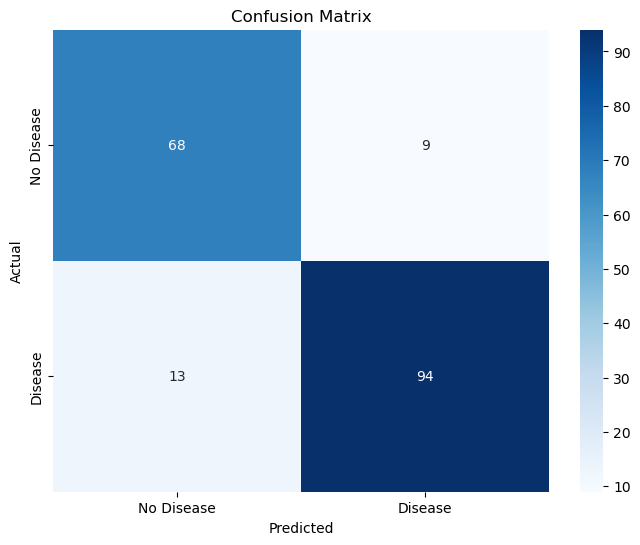

In [164]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [160]:
print(classification_report(ytest,model.predict(xtest)))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86        77
           1       0.91      0.88      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



## Briefly explain the model results and important features
### lets see the most important features using correlation

In [119]:
corr = data.corr()

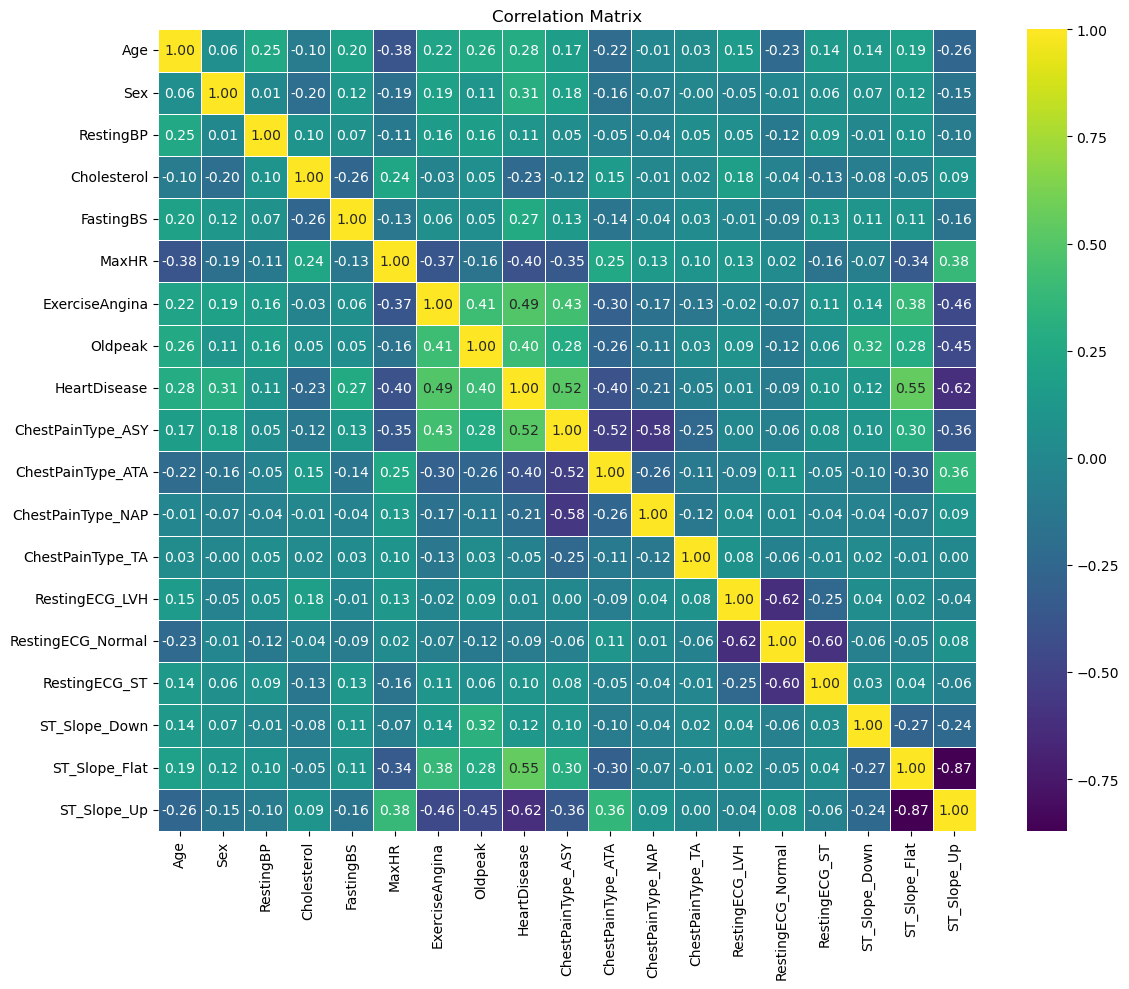

In [166]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap='viridis',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar=True
)

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

In [129]:
model.feature_importances_
importance = pd.DataFrame({
    'Feature': xtrain.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

              Feature  Importance
17        ST_Slope_Up    0.151965
7             Oldpeak    0.110013
16      ST_Slope_Flat    0.103289
6      ExerciseAngina    0.098970
5               MaxHR    0.096400
3         Cholesterol    0.092187
0                 Age    0.081011
8   ChestPainType_ASY    0.068737
2           RestingBP    0.063869
1                 Sex    0.033790
9   ChestPainType_ATA    0.023009
4           FastingBS    0.017936
10  ChestPainType_NAP    0.013979
12     RestingECG_LVH    0.011919
13  RestingECG_Normal    0.010641
14      RestingECG_ST    0.009640
15      ST_Slope_Down    0.007388
11   ChestPainType_TA    0.005257


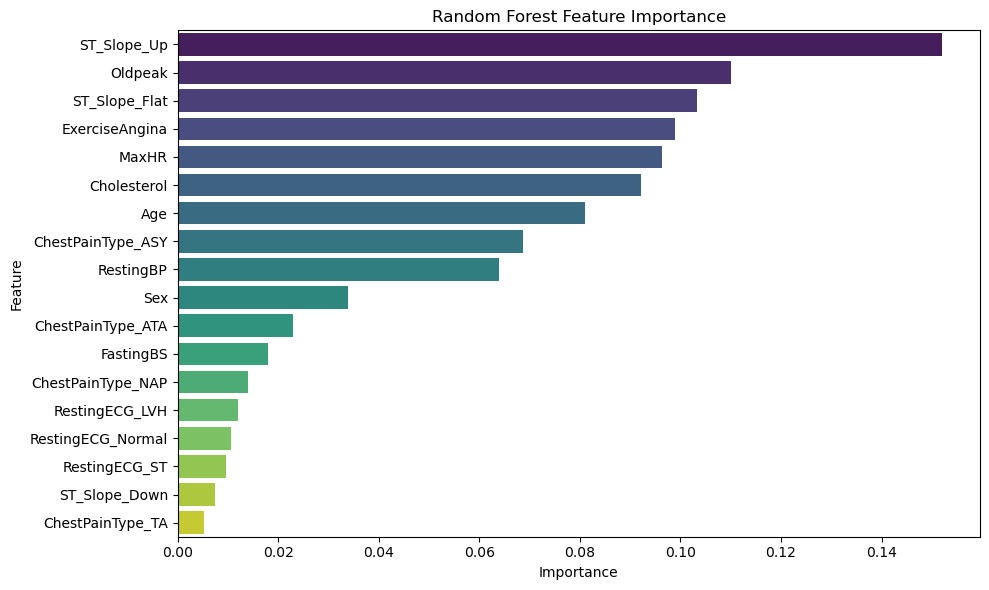

In [186]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.sort_values('Importance', ascending=False),
    palette='viridis'
)

plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()